# Unit 2: **Basic ideas of molecular-kinetic theory (MKT) of gases. Critical states. Math review: Differentiation.**

# Significance

* **Kinetic molecular interpretation**
– Linking macroscopic pressure and temperature to molecular collisions; useful in reaction kinetics and spectroscopy.

* **Reaction kinetics**
– Collision theory and Maxwell–Boltzmann velocity distributions are essential for understanding reaction rates and activation energies.

* **Transport phenomena**
– Diffusion, thermal conductivity, and viscosity of gases follow directly from MKT and are critical in chemical engineering processes.

* **Phase transitions**
– Understanding compressibility, critical points, and deviations from ideality in liquefaction of gases (e.g., liquefied CO₂ as solvent).

* **Cryogenics in medicine**
– Use of liquefied gases (O₂, N₂) in storage of biological samples and cryosurgery.


# 1. Theory

## 1.1. Core Postulates of MKT

1. **Molecules are in constant random motion.**  
   Gas molecules move in all directions with a wide distribution of speeds.

2. **Molecules are point-like compared to distances between them.**  
   Their own volume is negligible relative to the volume of the container.

3. **Collisions are perfectly elastic.**  
   Kinetic energy and momentum are conserved in molecule–molecule and molecule–wall collisions.

4. **No long-range forces (ideal gas assumption).**  
   Molecules interact only during collisions (no attraction/repulsion otherwise).

## 1.2. Key Results
- **Pressure of a gas** arises from collisions of molecules with the container walls:  
  $$
  P = \frac{1}{3} \frac{N}{V} m \langle v^2 \rangle
  $$
  where:
  - N - the number of particles
  - V - volume
  - m - mass of the molecule (NOT the molecular mass!!!)
  
- **Temperature is a measure of average kinetic energy:**  
  $$
  \frac{3}{2}k_B T = \frac{1}{2} m \langle v^2 \rangle \leftrightarrow \frac{3}{2}R T = \frac{1}{2} M \langle v^2 \rangle
  $$
  where:
  - $R = 8.314 \frac{J}{mol\cdot K}$ - ideal gas constant
  - $k_B = \frac{R}{N_A} = 1.38 \cdot 10^{-23} \frac{J}{K}$ - Boltzmann constant
  - $N_A = 6.022 \cdot 10^{23} \mathrm{mol^{-1}}$ - Avogadro's number

- **Distribution of molecular speeds (Maxwell–Boltzmann distribution):**  
  Probability density function for finding a molecule with speed between \(v\) and \(v + dv\):  
  $$
  f(v) = 4\pi \left( \frac{m}{2 \pi k_B T} \right)^{3/2} v^2 e^{-\frac{mv^2}{2k_B T}} = \
         4\pi \left( \frac{M}{2 \pi R T} \right)^{3/2} v^2 e^{-\frac{Mv^2}{2R T}}
  $$
  with normalization
  $$
  \int_0^\infty f(v)\,dv = 1
  $$

- **Characteristic speeds:**
  $$
  v_{mp} = \sqrt{\frac{2k_BT}{m}}, \quad
  v_{mean} = \sqrt{\frac{8k_BT}{\pi m}}, \quad
  v_{rms} = \sqrt{\frac{3k_BT}{m}}
  $$

  or, using molar masses: 
  
  $$
  v_{mp} = \sqrt{\frac{2RT}{M}}, \quad
  v_{mean} = \sqrt{\frac{8RT}{\pi M}}, \quad
  v_{rms} = \sqrt{\frac{3RT}{M}}
  $$


In [1]:
N_A = 6.022e23
R = 8.314 
k_B = R/N_A
print(k_B)

1.3806044503487214e-23


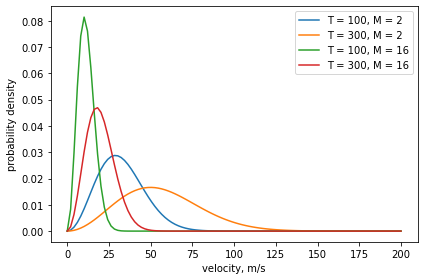

In [12]:
import numpy as np
import matplotlib.pyplot as plt

v = np.linspace(0, 200, 100)
M1 = 2 # H2
M2 = 16 # O2
T1 = 100
T2 = 300

for M in [M1, M2]:
    for T in [T1, T2]:
        f = 4*np.pi*(M/(2*np.pi*R*T))**1.5 * v**2 * np.exp(-M * v**2 / (2.0 * R * T) )
        plt.plot(v, f, label=F"T = {T}, M = {M}")
plt.xlabel("velocity, m/s")
plt.ylabel("probability density")
plt.legend()
plt.tight_layout()
plt.show()

## 1.3 Critical States

### Critical Point
- The **critical point** is the unique temperature and pressure above which the liquid and gas phases become indistinguishable.
- At the **critical temperature** \($T_c$\), the gas cannot be liquefied no matter how much pressure is applied.
- At the **critical pressure** \($P_c$\), the gas–liquid boundary disappears.
- The **critical density** corresponds to the density at this point.

### Mathematical Definition of Critical Point
For a fluid described by an equation of state \($P = P(V,T)$\), the **critical point** is defined by the following conditions on the isotherm:

$$
\left(\frac{\partial P}{\partial V}\right)_{T=T_c} = 0, 
\quad
\left(\frac{\partial^2 P}{\partial V^2}\right)_{T=T_c} = 0
$$

These conditions mean that at \($T = T_c$\), the \($P$\)–\($V$\) curve has a point of inflection: the distinction between liquid and gas phases disappears.


### Reduced Variables (Law of Corresponding States)
To make equations of state dimensionless, we introduce **reduced variables** normalized by their critical values:

$$
T_r = \frac{T}{T_c}, 
\quad
P_r = \frac{P}{P_c}, 
\quad
V_r = \frac{V}{V_c}
$$

- Substances often exhibit **similar behavior** when expressed in terms of reduced variables → **law of corresponding states**.  
- For example, the **van der Waals equation** in reduced form is nearly universal across different gases (does not depend on the parameters a and b entering the original vdW equation of state)


### Real-Life Uses
- **Carbon dioxide**: \($T_c = 304.25 \, \text{K}, \; P_c = 7.39 \, \text{MPa}$\).  
  Basis for **supercritical CO₂ extraction** (e.g., coffee decaffeination).
- **Water**: \($T_c = 647 \, \text{K}, \; P_c = 22.1 \, \text{MPa}$\).  
  Supercritical water is used in waste treatment and green chemistry.
  

## 1.4 Gas Compressibility Factor

### Definition and Properties
The **compressibility factor** \($Z$\) is defined as the ratio of the molar volume of a real gas to that of an ideal gas at the same \($T, P$\):

$$
Z = \frac{P V_m}{R T}
$$

- For an **ideal gas**, \($Z = 1$\).
- Deviations from unity measure how much a real gas departs from ideal behavior:
  - \($Z < 1$\): attractive forces dominate (gas is more compressible).
  - \($Z > 1$\): repulsive forces dominate (gas resists compression).


### Compressibility Factor at Critical Point
By definition of reduced variables, at the critical point:

$$
Z_c = \frac{P_c V_c}{R T_c}
$$

- For a **van der Waals gas**:
  $$
  Z_c = \frac{3}{8} = 0.375
  $$
- Experimentally, most gases have \($Z_c \approx 0.27 \pm 0.03$\).  
  This near-universality supports the law of corresponding states.

# 2. Examples

## Example 1

At what temperature is the average speed of oxygen molecules is 500 m/s?

### Solution

In [1]:
# We use the equation v_rms = sqrt(3R*T/M)
M = 16*2 * 1e-3 # kg/mol 
R = 8.314 # J/mol*K
v_rms = 500.0 # m/s

T = M * v_rms**2 /(3*R)

print(T)

320.7441263731858


### Additional elaboration

#### Step 1: RMS speed formula with molar quantities

$$
v_\text{rms} = \sqrt{\frac{3 R T}{M}}
$$

where:  
- \(M\) = molar mass (kg/mol)  
- \(R = 8.314\ \text{J/(mol·K)}\)  
- \(T\) = absolute temperature (K)  

Rearranging:

$$
T = \frac{M v_\text{rms}^2}{3 R}
$$

#### Step 2: Substitute values

- Oxygen: \($O_2$\), \($M = 32\ \text{g/mol} = 0.032\ \text{kg/mol}$\)  
- \($v_\text{rms} = 500\ \text{m/s}$\)  
- \($R = 8.314\ \text{J/(mol·K)}$\)  

$$
T = \frac{0.032 \cdot 500^2}{3 \cdot 8.314}
$$

Step by step:

1. \($500^2 = 250{,}000$\)  
2. Multiply by 0.032: \($250{,}000 \cdot 0.032 = 8{,}000$\)  
3. Multiply 3 × 8.314 = 24.942  
4. Divide: \($T = \frac{8{,}000}{24.942} \approx 320.6\ \text{K}$\) 

## Example 2
The compressibility coefficient for CO2 at T=0℃ and P=100 atm is Z=0.2007. Compute the volume (in L) of 0.1 mol of CO2 under these conditions using: a) ideal gas law; b) the compressibility coefficient

### Solution

In [2]:
# Constants
mmHg2atm = 1.0/760.0  # P[atm] = P[mmHg] * mmHg2atm
R = 0.0821 # L*atm/mol*K
atm2Pa = 101325.0 #  P[Pa] = P[atm] * atm2Pa

In [3]:
# First, compute the volume of the ideal gas:

P = 100 # atm
T = 0 + 273.15 # convert to K
n = 0.1 # mol

V_id = n * R * T/P

# Second, compute the actual volume using Z = V/V_id = 0.2007
Z = 0.2007 # compressibility factor
V = V_id * Z

print(F"ideal gas volume = {V_id} L; actual gas volume = {V} L")

ideal gas volume = 0.022425615 L; actual gas volume = 0.0045008209305 L


## Example 3
Compute the critical parameters $V_{\rm crit}$, $P_{\rm crit}$, $T_{\rm crit}$ for the Berthelot equation of state:

$$
P = \frac{R T}{V_m - b} - \frac{a}{T V_m^2}
$$

### Solution

At the critical point, the following conditions hold:

$$
\left(\frac{\partial P}{\partial V_m}\right)_T = 0, \quad 
\left(\frac{\partial^2 P}{\partial V_m^2}\right)_T = 0
$$

Compute derivatives:

$$
\frac{\partial P}{\partial V_m} = - \frac{R T}{(V_m - b)^2} + \frac{2 a}{T V_m^3} = 0
$$

$$
\frac{\partial^2 P}{\partial V_m^2} = \frac{2 R T}{(V_m - b)^3} - \frac{6 a}{T V_m^4} = 0
$$

Divide the second equation by the first to eliminate $R T$ and $a/T$:

$$
\frac{1}{V_m - b} = \frac{3}{2} \frac{1}{V_m} \quad \Rightarrow \quad V_{\rm crit} = 3 b
$$

Use the first derivative to solve for $T_{\rm crit}$:

$$
R T_{\rm crit}^2 = \frac{8}{27} \frac{a}{b} \quad \Rightarrow \quad 
T_{\rm crit} = \sqrt{\frac{8 a}{27 b R}} = \frac{2 \sqrt{6}}{9} \sqrt{\frac{a}{R b}}
$$

Compute $P_{\rm crit}$ from the EOS at $V_m = 3b$:

$$
P_{\rm crit} = \frac{R T_{\rm crit}}{2 b} - \frac{a}{9 b^2 T_{\rm crit}} = \frac{a}{27 b^2 T_{\rm crit}} 
= \frac{1}{36} \sqrt{\frac{6 a R}{b^3}}
$$

### Final Results

$$
V_{\rm crit} = 3 b
$$

$$
T_{\rm crit} = \sqrt{\frac{8 a}{27 b R}} = \frac{2 \sqrt{6}}{9} \sqrt{\frac{a}{R b}}
$$

$$
P_{\rm crit} = \frac{1}{36} \sqrt{\frac{6 a R}{b^3}}
$$


## Example 4

Using critical parameters obtained in problem 2, derive the reduced Berthelot equation of state and show that it does not contain parameters a and b.

### Solution

Berthelot EOS:
$$
P=\frac{R T}{V_m-b}-\frac{a}{T V_m^2}.
$$

Critical parameters (from previous result):
$$
V_c=3b,\qquad
T_c=\sqrt{\frac{8a}{27 b R}},\qquad
P_c=\frac{1}{36}\sqrt{\frac{6 a R}{b^3}}.
$$

Define reduced variables:
$$
V_r=\frac{V_m}{V_c},\qquad T_r=\frac{T}{T_c},\qquad P_r=\frac{P}{P_c}.
$$

Write \($V_m=V_r V_c=3b$\,$V_r$\) and \($T=T_r T_c$\) and substitute into the EOS:
$$
P=\frac{R T_r T_c}{3b V_r-b}-\frac{a}{T_r T_c\,(3b V_r)^2}
=\left(\frac{R T_c}{b}\right)\frac{T_r}{3V_r-1}-\left(\frac{a}{b^2 T_c}\right)\frac{1}{9\,T_r\,V_r^2}.
$$

Using the critical relations, note the identities
$$
\frac{R T_c}{b}=8P_c,\qquad \frac{a}{b^2 T_c}=27P_c,
$$
which follow directly from the expressions for \($T_c$\) and \($P_c$\).

Hence
$$
P=P_c\left[\frac{8\,T_r}{3V_r-1}-\frac{27}{9\,T_r\,V_r^2}\right]
= P_c\left[\frac{8\,T_r}{3V_r-1}-\frac{3}{T_r\,V_r^2}\right].
$$

Therefore, the **reduced equation of state** is
$$
\boxed{\,P_r=\frac{P}{P_c}=\frac{8\,T_r}{3V_r-1}-\frac{3}{T_r\,V_r^2}\,}
$$
which contains **no** appearance of the parameters \(a\) or \(b\).

# 3. Problems

# 4. Solutions